# H1 — REC > 0

Simple one-sample t-tests by condition.

Hypothesis: Recognition Memory Index (REC) is above 0.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp

sns.set(style='whitegrid', context='talk')

df = pd.read_csv(r'/home/achyutananda-sahoo/Desktop/IIITH-BRSM/PROJECT/DATA/compiled_preprocessed.csv')
df['boundary_position'] = pd.Categorical(df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True)

In [2]:
def p_resp(data, trial_type, response, boundary=None):
    x = data[data['trial_type'] == trial_type]
    if boundary is not None:
        x = x[x['boundary_position'] == boundary]
    if x.empty:
        return np.nan
    return (x['user_response'] == response).mean()

rows = []
for (pid, cond), sub in df.groupby(['participant_id', 'condition']):
    foil_old = p_resp(sub, 'Foil', 'Target')
    rec_vals = []
    for pos in ['Pre', 'Mid', 'Post']:
        hit = p_resp(sub, 'Target', 'Target', pos)
        rec_vals.append(hit - foil_old)
    rows.append({'participant_id': pid, 'condition': cond, 'REC': np.nanmean(rec_vals)})

rec_df = pd.DataFrame(rows)

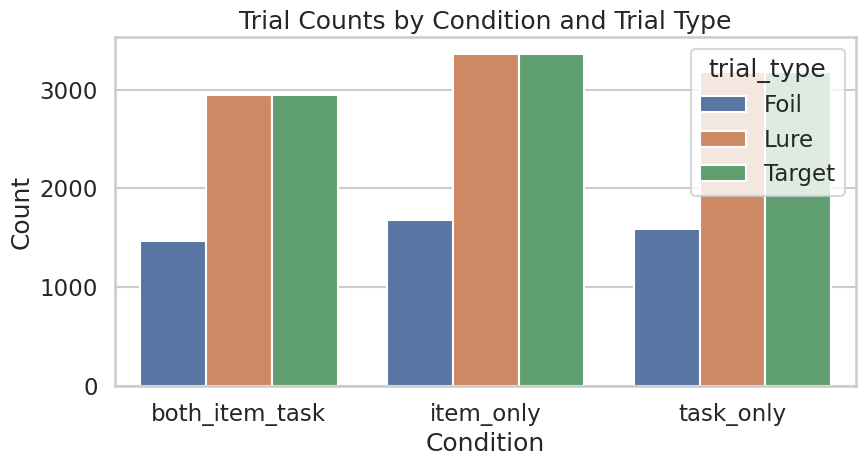

In [3]:
# Quick data visualization: trial counts by condition
trial_counts = df.groupby(['condition', 'trial_type']).size().reset_index(name='n')
plt.figure(figsize=(9, 5))
sns.barplot(data=trial_counts, x='condition', y='n', hue='trial_type')
plt.title('Trial Counts by Condition and Trial Type')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
result = []
for cond, sub in rec_df.groupby('condition'):
    vals = sub['REC'].dropna()
    test = ttest_1samp(vals, popmean=0.0, alternative='greater')
    result.append({
        'condition': cond,
        'n': len(vals),
        'mean_REC': vals.mean(),
        't_stat': test.statistic,
        'p_value': test.pvalue,
        'supported (p<.05)': test.pvalue < 0.05
    })

result_df = pd.DataFrame(result).sort_values('condition')
display(result_df)

,condition,n,mean_REC,t_stat,p_value,supported (p<.05)
0,both_item_task,49,0.602041,30.499114,2.228821e-33,True
1,item_only,56,0.633929,30.962585,8.671863e-37,True
2,task_only,53,0.595912,24.879847,7.565724e-31,True


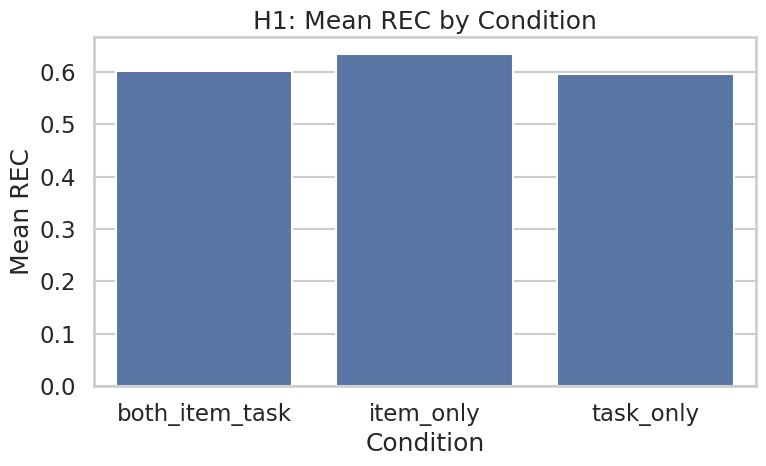

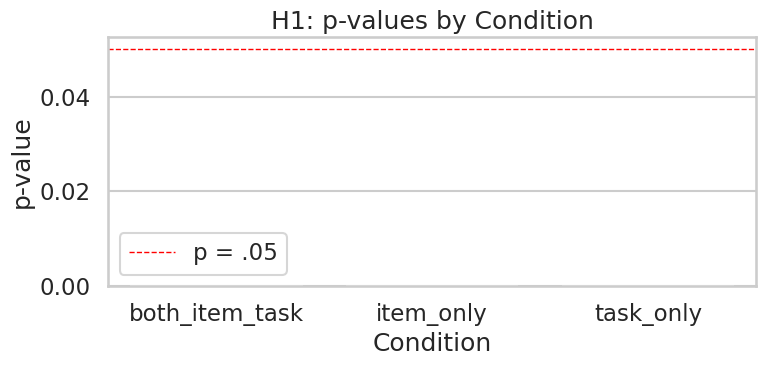

In [5]:
# Visualization of REC means and p-values
plot_df = result_df.copy()
plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x='condition', y='mean_REC')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('H1: Mean REC by Condition')
plt.ylabel('Mean REC')
plt.xlabel('Condition')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x='condition', y='p_value')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = .05')
plt.title('H1: p-values by Condition')
plt.ylabel('p-value')
plt.xlabel('Condition')
plt.legend()
plt.tight_layout()
plt.show()